In [1]:
# Numerical Computation
import numpy as np

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

# Save Model
import joblib

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [2]:
df = pd.read_excel("../data/Rising-Waters-Flood-Prediction-Dataset/flood dataset.xlsx")

In [18]:
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [19]:
print("Dataset Shape:", df.shape)

Dataset Shape: (115, 11)


In [20]:
print(df.columns)

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='str')


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [22]:
df.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [23]:
df.isnull().any()

Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

In [24]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


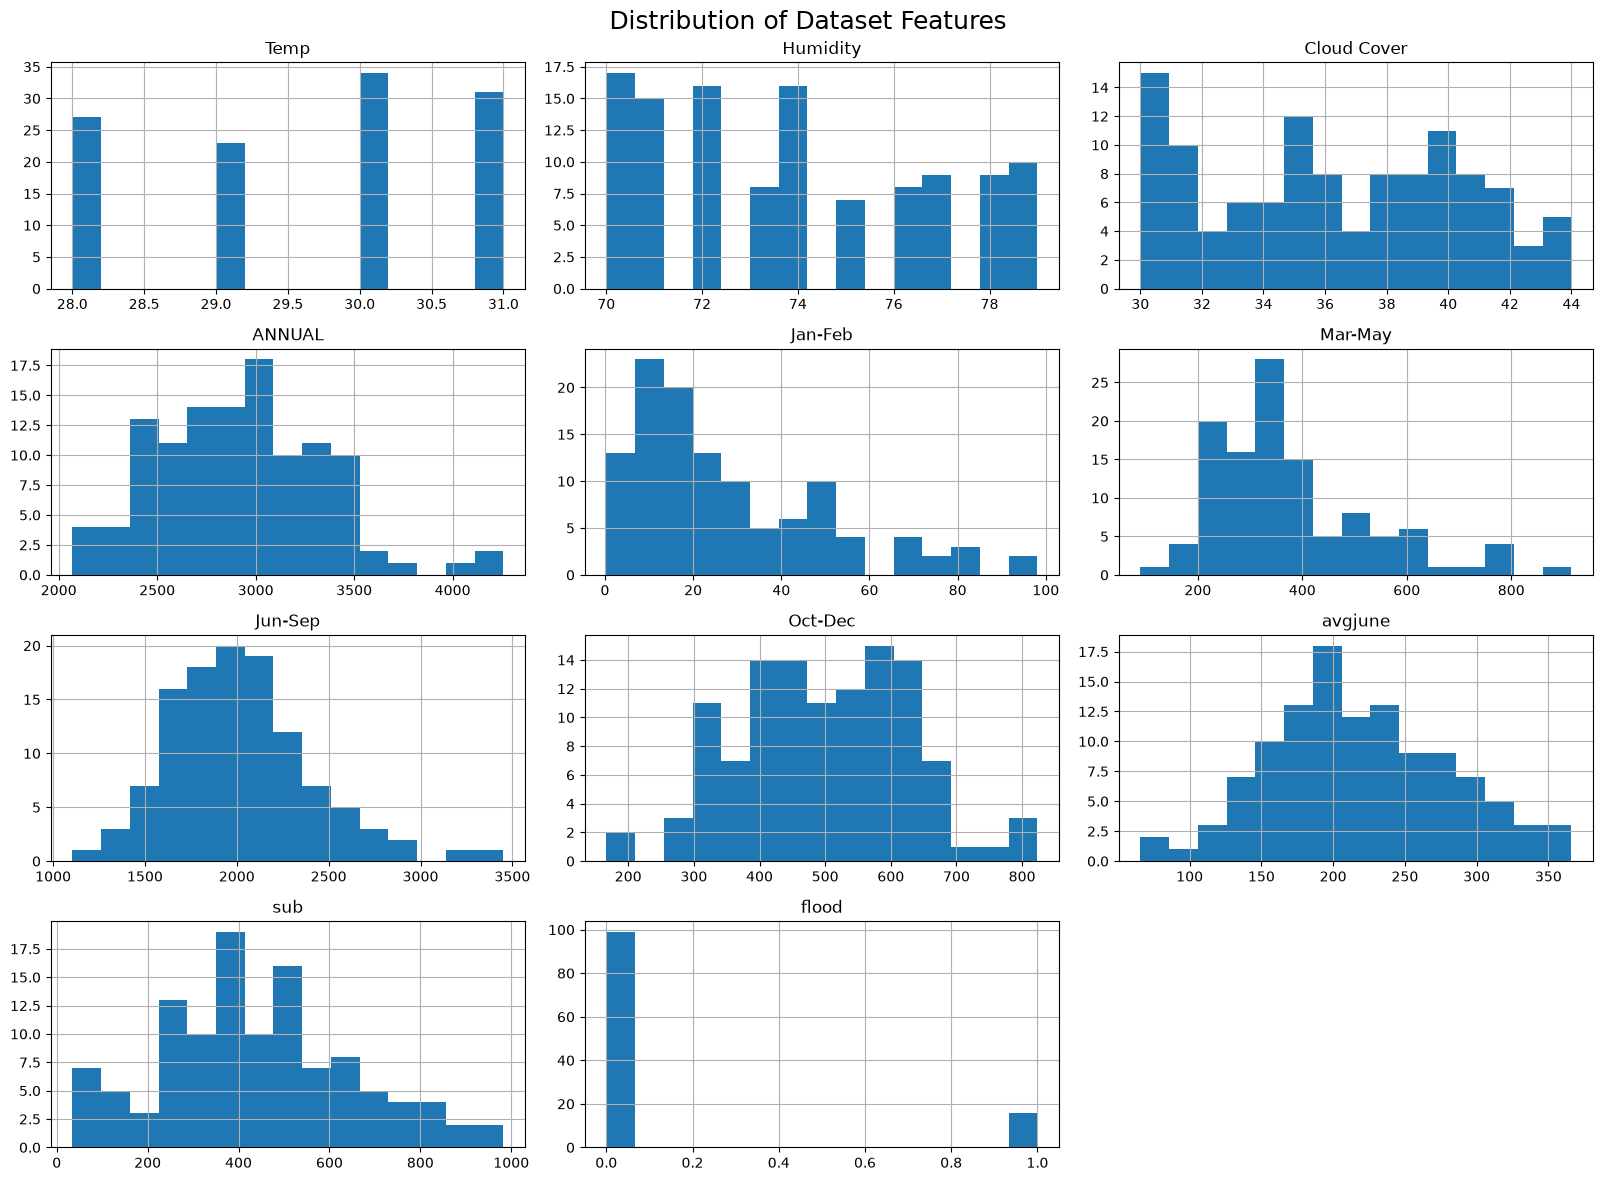

In [25]:
# Histogram for all numerical features

df.hist(figsize=(16,12), bins=15)
plt.suptitle("Distribution of Dataset Features", fontsize=18)
plt.tight_layout()
plt.show()

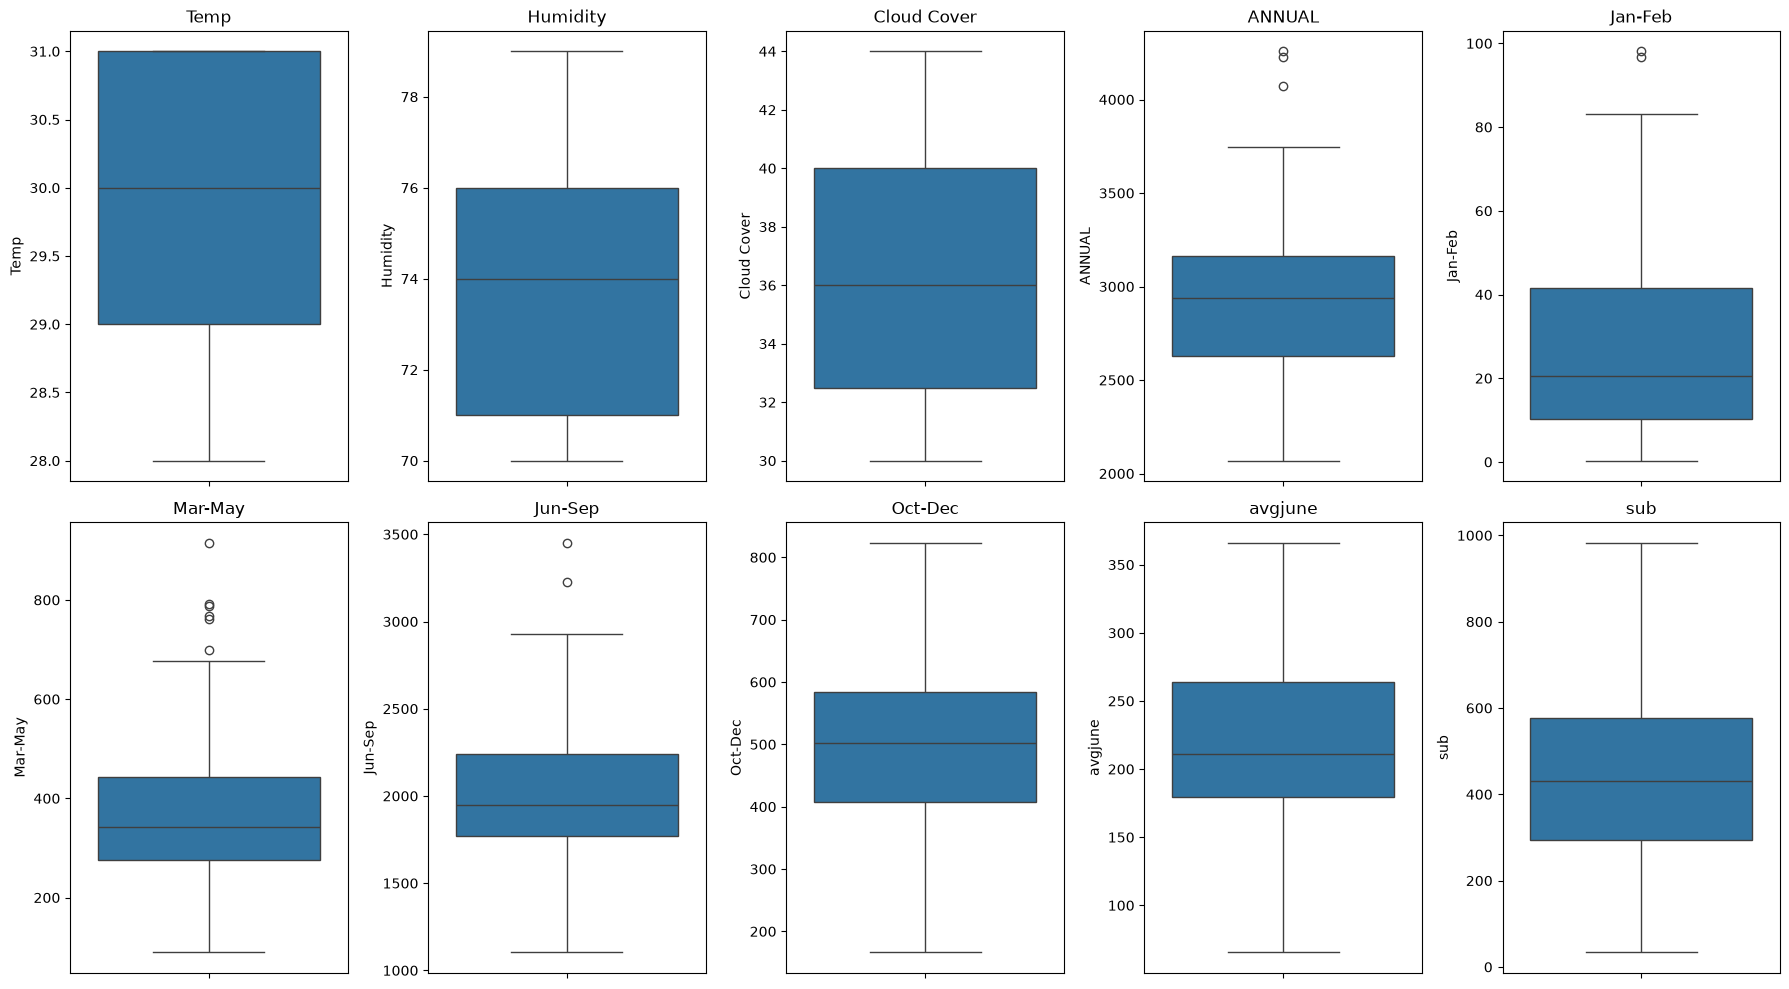

In [26]:
plt.figure(figsize=(18,10))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(2,5,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

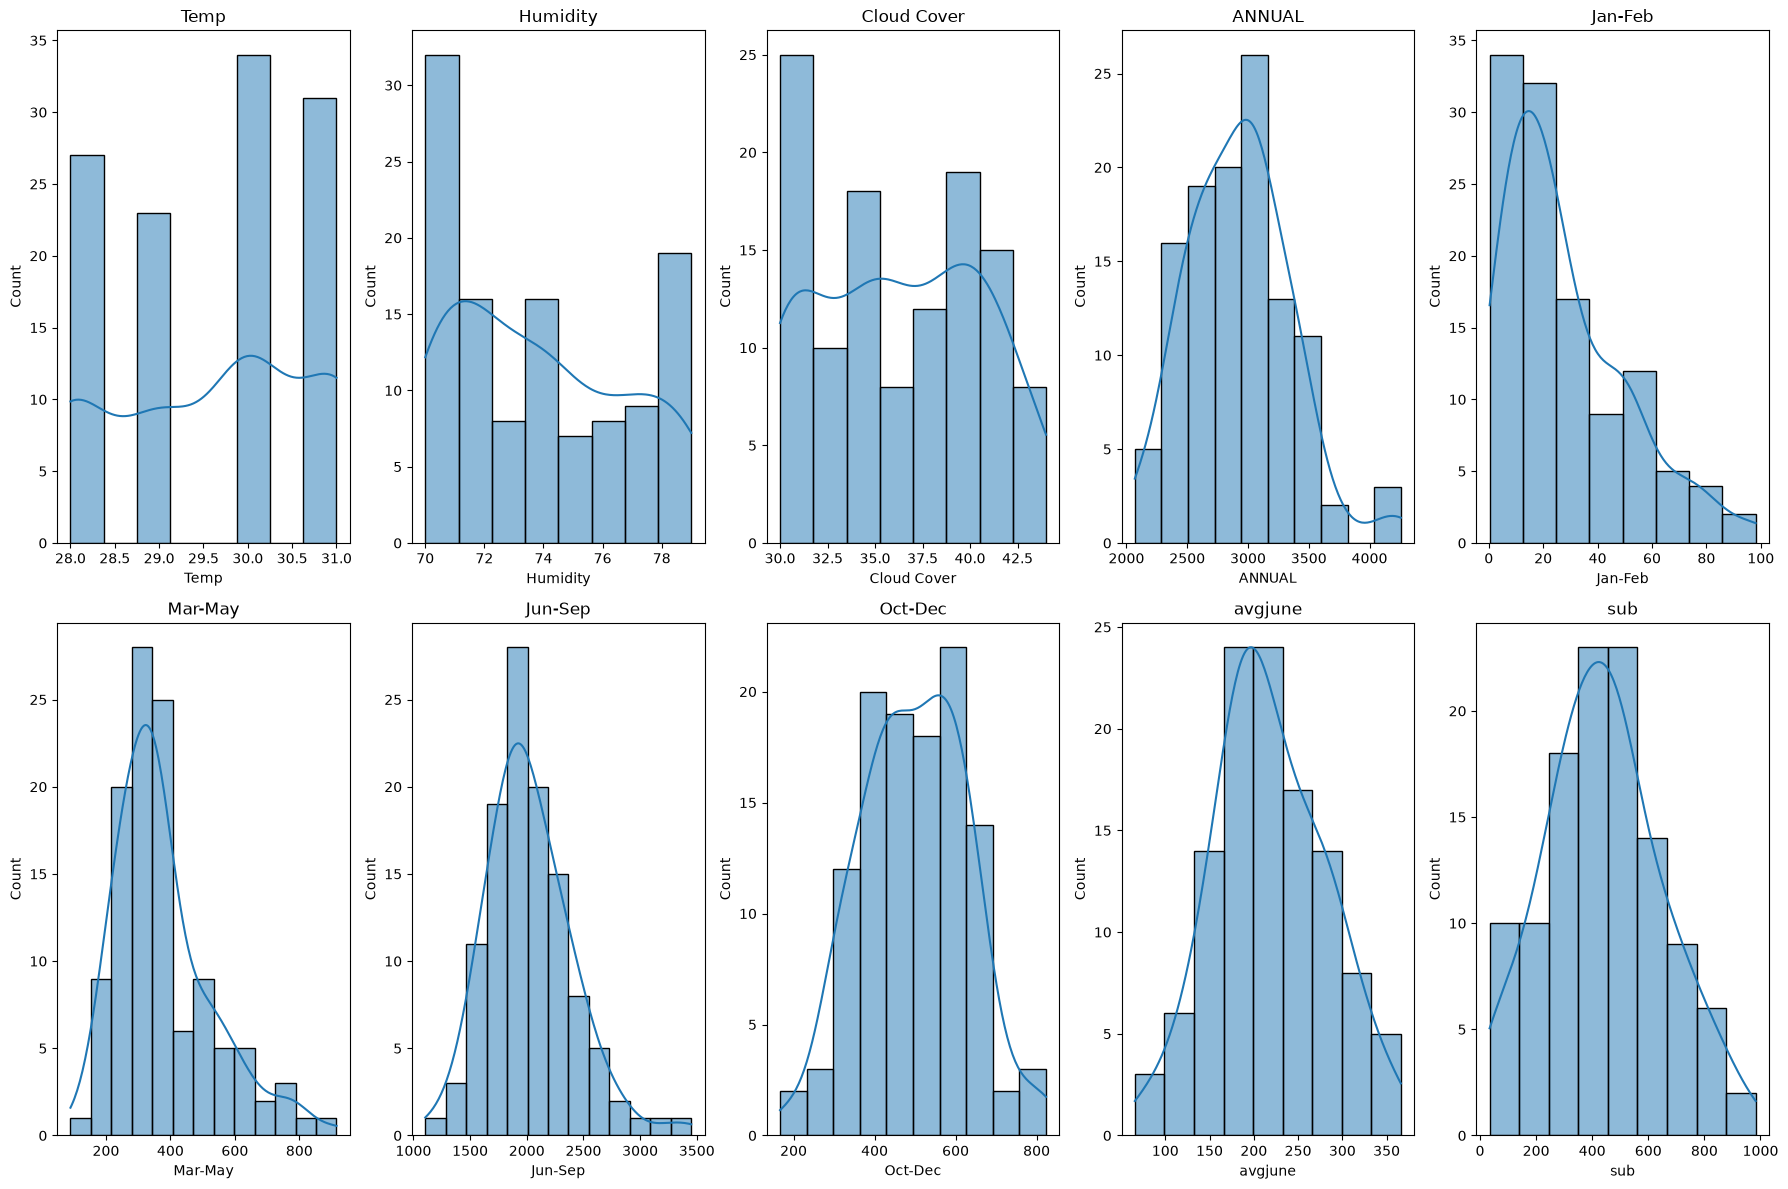

In [27]:
plt.figure(figsize=(18,12))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(2,5,i)
    sns.histplot(df[column], kde=True)
    plt.title(column)

plt.tight_layout()
plt.show()

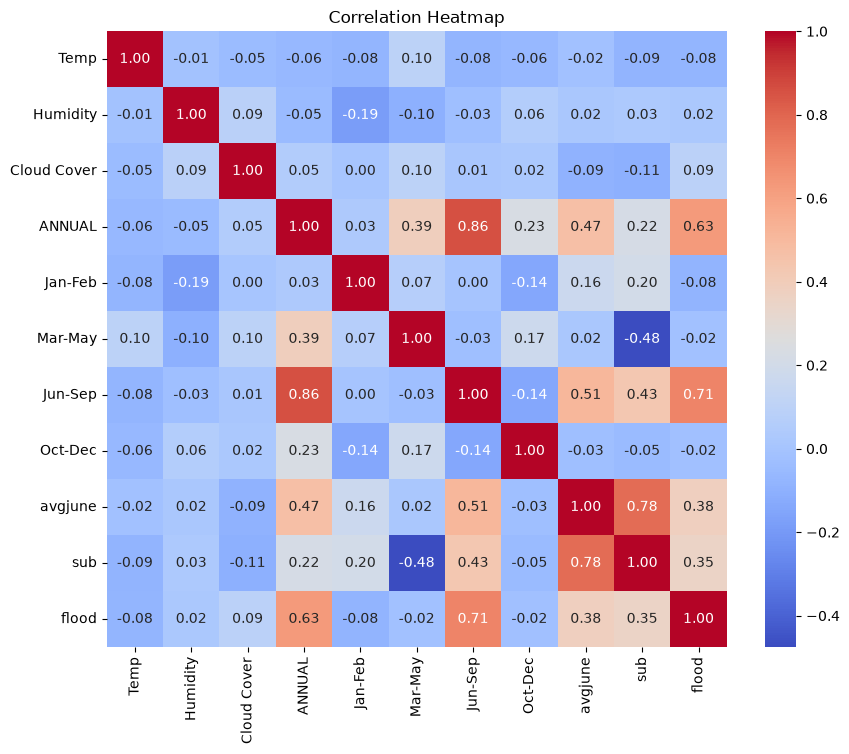

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [4]:
# Creating a copy of dataset

df_processed = df.copy()

# Features only (excluding target)

features = df_processed.columns[:-1]

for column in features:

    Q1 = df_processed[column].quantile(0.25)
    Q3 = df_processed[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_processed[column] = np.where(
        df_processed[column] < lower,
        lower,
        np.where(df_processed[column] > upper,
                 upper,
                 df_processed[column])
    )

print("Outliers handled successfully.")

Outliers handled successfully.


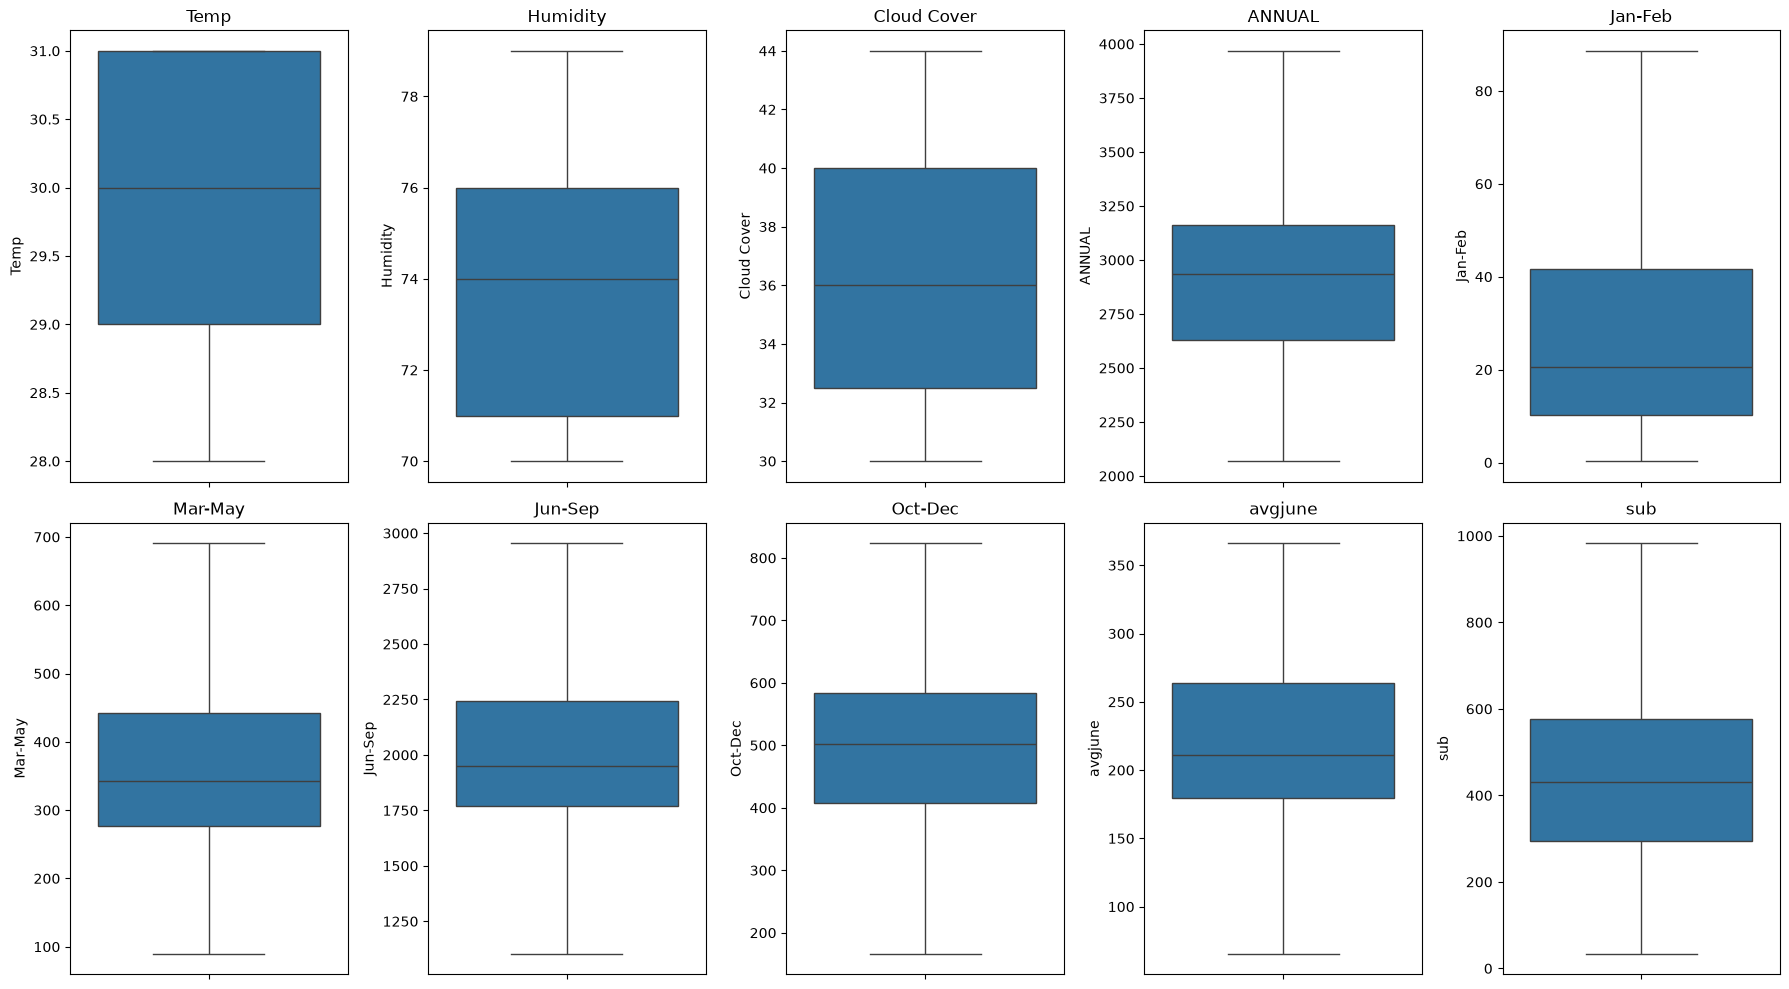

In [29]:
plt.figure(figsize=(18,10))

for i,column in enumerate(df_processed.columns[:-1],1):
    plt.subplot(2,5,i)
    sns.boxplot(y=df_processed[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [5]:
# Independent Variables (Features)
X = df_processed.drop("flood", axis=1)

# Dependent Variable (Target)
y = df_processed["flood"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (115, 10)
Target Shape: (115,)


In [8]:
# Splitting Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (86, 10)
Testing Data: (29, 10)


In [9]:
# Feature Scaling using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


In [30]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save scaler
joblib.dump(scaler, "../models/transform.save")

print("Scaler saved successfully!")

Scaler saved successfully!


In [10]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols)

if len(categorical_cols) > 0:
    le = LabelEncoder()

    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])

    print("Categorical columns encoded successfully.")
else:
    print("No categorical columns found.")

Categorical Columns:
Index([], dtype='str')
No categorical columns found.


In [31]:
X.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub
0,29.0,70.0,30.0,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9
1,28.0,75.0,40.0,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4
2,28.0,75.0,42.0,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9
3,29.0,71.0,44.0,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5
4,31.0,74.0,40.0,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9


In [32]:
y.head()

0    0
1    1
2    0
3    0
4    0
Name: flood, dtype: int64

In [ ]:
x = df.iloc[:, 2:7].values

In [ ]:
y=df.iloc[:,9:].values

In [11]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Data: (86, 10)
Testing Data : (29, 10)
Training Labels: (86,)
Testing Labels : (29,)


Decision Tree Accuracy: 96.55 %

Confusion Matrix
[[25  0]
 [ 1  3]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       1.00      0.75      0.86         4

    accuracy                           0.97        29
   macro avg       0.98      0.88      0.92        29
weighted avg       0.97      0.97      0.96        29



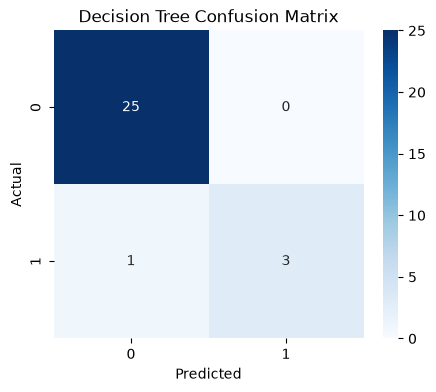

In [12]:
# ==============================
# Decision Tree Model
# ==============================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train Model
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

print("=" * 60)
print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)

print("\nConfusion Matrix")
print(cm)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, dt_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Random Forest Accuracy: 96.55 %

Confusion Matrix
[[25  0]
 [ 1  3]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       1.00      0.75      0.86         4

    accuracy                           0.97        29
   macro avg       0.98      0.88      0.92        29
weighted avg       0.97      0.97      0.96        29



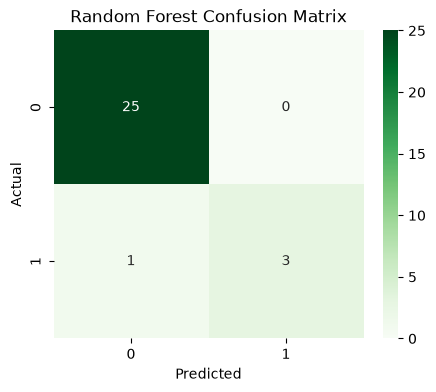

In [13]:
# ==============================
# Random Forest Model
# ==============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=" * 60)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

print("\nConfusion Matrix")
print(cm)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, rf_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

KNN Accuracy: 89.66 %

Confusion Matrix
[[24  1]
 [ 2  2]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        25
           1       0.67      0.50      0.57         4

    accuracy                           0.90        29
   macro avg       0.79      0.73      0.76        29
weighted avg       0.89      0.90      0.89        29



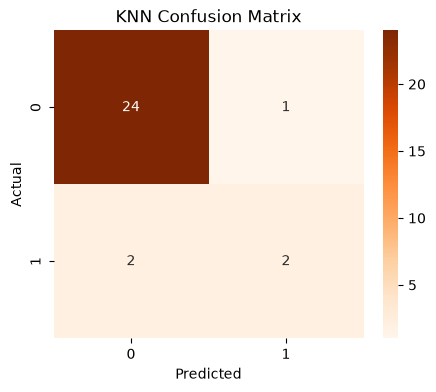

In [14]:
# ==============================
# K-Nearest Neighbors (KNN) Model
# ==============================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train Model
knn_model.fit(X_train_scaled, y_train)

# Prediction
knn_pred = knn_model.predict(X_test_scaled)

# Accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)

print("=" * 60)
print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, knn_pred)

print("\nConfusion Matrix")
print(cm)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, knn_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

XGBoost Accuracy: 96.55 %

Confusion Matrix
[[25  0]
 [ 1  3]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       1.00      0.75      0.86         4

    accuracy                           0.97        29
   macro avg       0.98      0.88      0.92        29
weighted avg       0.97      0.97      0.96        29



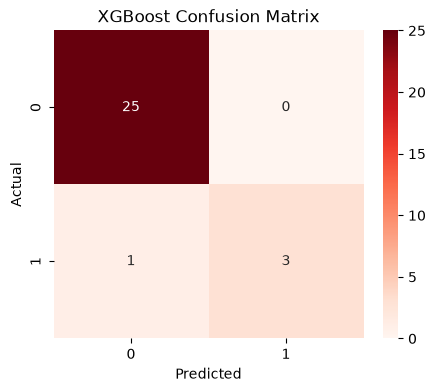

In [46]:
# ==============================
# Gradient Boosting Model (Called XGBoost in Project)
# ==============================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Model
xgb_model = GradientBoostingClassifier(
    random_state=42
)

# Train Model
xgb_model.fit(X_train_scaled, y_train)

# Prediction
xgb_pred = xgb_model.predict(X_test_scaled)

# Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("=" * 60)
print("XGBoost Accuracy:", round(xgb_accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)

print("\nConfusion Matrix")
print(cm)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

MODEL COMPARISON
           Model  Accuracy (%)
0  Decision Tree         96.55
1  Random Forest         96.55
2            KNN         89.66
3        XGBoost         96.55


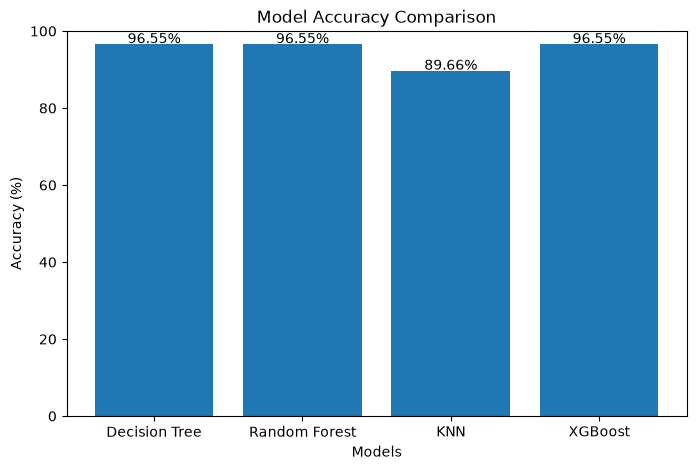

In [33]:
# ==============================
# Model Comparison
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],
    "Accuracy (%)": [
        round(dt_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(knn_accuracy * 100, 2),
        round(xgb_accuracy * 100, 2)
    ]
})



print("=" * 45)
print("MODEL COMPARISON")
print("=" * 45)
print(comparison)

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy (%)"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(comparison["Accuracy (%)"]):
    plt.text(i, value + 0.3, f"{value:.2f}%", ha="center")

plt.ylim(0, 100)
plt.show()

In [47]:
# ==============================
# Save Final Model
# ==============================

import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(xgb_model, "../models/floods.save")

print("Flood Prediction Model saved successfully!")

Flood Prediction Model saved successfully!


In [35]:
import os

print(os.listdir("../models"))

['floods.save', 'transform.save']


In [36]:
loaded_model = joblib.load("../models/floods.save")

print(type(loaded_model))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [37]:
loaded_scaler = joblib.load("../models/transform.save")

print(type(loaded_scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>
